[시스템] Linux | Python 3.12.13 | mpl 3.10.0

[방법 0] koreanize-matplotlib 패키지 시도...
  → 패키지 없음, pip install 시도...


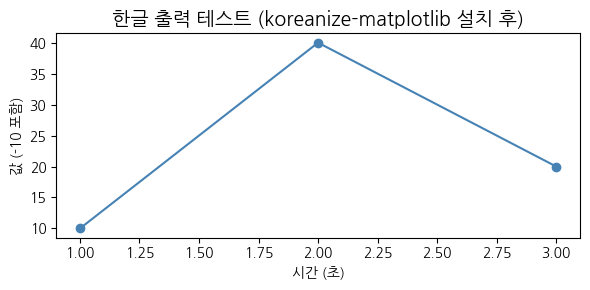

✅ 성공: (koreanize-matplotlib 설치 후)

🎉 한글 폰트 설정 완료!
   적용 폰트  : koreanize-matplotlib
   현재 rcParams: ['NanumGothic']

앞으로 이 셀을 노트북 상단에 두거나, 아래 한 줄만 사용하세요:
   import matplotlib as mpl
   mpl.rcParams['font.family'] = 'koreanize-matplotlib'
   mpl.rcParams['axes.unicode_minus'] = False


In [14]:
# ============================================================
#  matplotlib 한국어 폰트 자동 설정 셀
#  OS 감지 → 방법 1~4 순서대로 시도, 성공하면 테스트 그래프 출력
# ============================================================
import sys, os, platform, subprocess, shutil
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

succeeded = False
succeeded_font = None

# ── 공통 유틸 ──────────────────────────────────────────────
def clear_mpl_cache():
    """matplotlib 폰트 캐시 삭제 후 재빌드"""
    cache_dir = mpl.get_cachedir()
    for f in os.listdir(cache_dir):
        if f.startswith("font") and f.endswith(".json"):
            os.remove(os.path.join(cache_dir, f))
    fm._load_fontmanager(try_read_cache=False)   # 캐시 재빌드

def apply_font(family_name):
    """rcParams 에 폰트 적용 + 마이너스 부호 깨짐 방지"""
    mpl.rcParams['font.family'] = family_name
    mpl.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = family_name

def font_supports_korean(family_name):
    """해당 font family 가 한글 글리프를 가지는지 확인"""
    try:
        path = fm.findfont(fm.FontProperties(family=family_name), fallback_to_default=False)
        fp   = fm.FontProperties(fname=path)
        # '한' 글자 (U+D55C) 의 글리프 인덱스가 0이면 미지원
        from matplotlib.ft2font import FT2Font
        font = FT2Font(path)
        return font.get_char_index(ord('한')) != 0
    except Exception:
        return False

def test_plot(title_suffix=""):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot([1, 2, 3], [10, 40, 20], marker='o', color='steelblue')
    ax.set_title(f"한글 출력 테스트 {title_suffix}", fontsize=14)
    ax.set_xlabel("시간 (초)")
    ax.set_ylabel("값 (-10 포함)")
    plt.tight_layout()
    plt.show()
    print(f"✅ 성공: {title_suffix}")

OS = platform.system()   # 'Windows' / 'Darwin' / 'Linux'
print(f"[시스템] {OS} | Python {sys.version.split()[0]} | mpl {mpl.__version__}")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# 방법 0 ▸ koreanize-matplotlib 패키지 (가장 간편)
# ══════════════════════════════════════════════════════════════
if not succeeded:
    print("\n[방법 0] koreanize-matplotlib 패키지 시도...")
    try:
        import koreanize_matplotlib  # noqa: F401  — import 만으로 폰트 적용됨
        mpl.rcParams['axes.unicode_minus'] = False
        test_plot("(koreanize-matplotlib)")
        succeeded = True; succeeded_font = "koreanize-matplotlib"
    except ImportError:
        print("  → 패키지 없음, pip install 시도...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install",
                                   "koreanize-matplotlib", "-q"])
            import koreanize_matplotlib  # noqa: F401
            mpl.rcParams['axes.unicode_minus'] = False
            test_plot("(koreanize-matplotlib 설치 후)")
            succeeded = True; succeeded_font = "koreanize-matplotlib"
        except Exception as e:
            print(f"  → 실패: {e}")

# ══════════════════════════════════════════════════════════════
# 방법 1 ▸ OS 기본 한글 폰트 직접 지정
# ══════════════════════════════════════════════════════════════
if not succeeded:
    print("\n[방법 1] OS 기본 한글 폰트 시도...")
    os_fonts = {
        "Windows": ["Malgun Gothic", "맑은 고딕", "Gulim", "Dotum"],
        "Darwin":  ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic"],
        "Linux":   ["NanumGothic", "NanumBarunGothic", "UnDotum", "UnBatang"],
    }
    for family in os_fonts.get(OS, []):
        try:
            path = fm.findfont(fm.FontProperties(family=family),
                               fallback_to_default=False)
            if "DejaVu" in path:   # fallback 이면 스킵
                continue
            apply_font(family)
            test_plot(f"({family})")
            succeeded = True; succeeded_font = family
            break
        except Exception as e:
            print(f"  → {family} 실패: {e}")

# ══════════════════════════════════════════════════════════════
# 방법 2 ▸ 시스템에 설치된 폰트 중 한글 지원 폰트 자동 탐색
# ══════════════════════════════════════════════════════════════
if not succeeded:
    print("\n[방법 2] 시스템 폰트 중 한글 지원 폰트 자동 탐색...")
    kr_keywords = ["nanum", "gothic", "batang", "gulim", "dotum", "malgun",
                   "apple", "un", "baekmuk", "kopub", "noto cjk", "source han"]
    candidates = [
        f for f in fm.fontManager.ttflist
        if any(kw in f.name.lower() for kw in kr_keywords)
    ]
    for font_entry in candidates:
        try:
            apply_font(font_entry.name)
            if font_supports_korean(font_entry.name):
                test_plot(f"({font_entry.name})")
                succeeded = True; succeeded_font = font_entry.name
                break
        except Exception:
            continue
    if not succeeded:
        print("  → 한글 지원 폰트를 찾지 못했습니다.")

# ══════════════════════════════════════════════════════════════
# 방법 3 ▸ Linux: apt 로 나눔폰트 설치 후 캐시 갱신
# ══════════════════════════════════════════════════════════════
if not succeeded and OS == "Linux":
    print("\n[방법 3] apt-get 으로 fonts-nanum 설치 시도 (Linux 전용)...")
    try:
        subprocess.check_call(["sudo", "apt-get", "install", "-y", "fonts-nanum"],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.check_call(["fc-cache", "-fv"],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        clear_mpl_cache()
        for family in ["NanumGothic", "NanumBarunGothic", "NanumMyeongjo"]:
            try:
                apply_font(family)
                test_plot(f"(apt 설치 후 {family})")
                succeeded = True; succeeded_font = family
                break
            except Exception:
                continue
    except Exception as e:
        print(f"  → apt 설치 실패: {e}")

# ══════════════════════════════════════════════════════════════
# 방법 4 ▸ NanumGothic .ttf 직접 다운로드 & 등록
# ══════════════════════════════════════════════════════════════
if not succeeded:
    print("\n[방법 4] NanumGothic TTF 직접 다운로드 & 등록...")
    try:
        import urllib.request
        font_url  = ("https://github.com/naver/nanumfont/raw/master/"
                     "fonts/NanumFontSetup_TTF_GOTHIC/NanumGothic.ttf")
        font_dir  = os.path.join(os.path.expanduser("~"), ".fonts")
        os.makedirs(font_dir, exist_ok=True)
        font_path = os.path.join(font_dir, "NanumGothic.ttf")

        if not os.path.exists(font_path):
            print("  → 다운로드 중...")
            urllib.request.urlretrieve(font_url, font_path)

        # matplotlib 폰트 디렉터리에도 복사
        mpl_font_dir = os.path.join(os.path.dirname(mpl.__file__),
                                    "mpl-data", "fonts", "ttf")
        shutil.copy2(font_path, mpl_font_dir)

        clear_mpl_cache()

        # FontProperties 로 직접 경로 지정
        fp = fm.FontProperties(fname=font_path)
        mpl.rcParams['font.family'] = fp.get_name()
        mpl.rcParams['axes.unicode_minus'] = False

        test_plot(f"(직접 다운로드 {fp.get_name()})")
        succeeded = True; succeeded_font = fp.get_name()
    except Exception as e:
        print(f"  → 실패: {e}")

# ══════════════════════════════════════════════════════════════
# 최종 결과 요약
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
if succeeded:
    print(f"🎉 한글 폰트 설정 완료!")
    print(f"   적용 폰트  : {succeeded_font}")
    print(f"   현재 rcParams: {mpl.rcParams['font.family']}")
    print("\n앞으로 이 셀을 노트북 상단에 두거나, 아래 한 줄만 사용하세요:")
    print(f"   import matplotlib as mpl")
    print(f"   mpl.rcParams['font.family'] = '{succeeded_font}'")
    print(f"   mpl.rcParams['axes.unicode_minus'] = False")
else:
    print("❌ 모든 방법 실패. 아래를 확인해 주세요:")
    print("   1) 인터넷 연결 상태")
    print("   2) sudo 권한 (Linux apt 설치)")
    print("   3) koreanize-matplotlib 수동 설치: pip install koreanize-matplotlib")

# 제안 A — 전천 카메라 구름 자동 분류 + 초단기 날씨 변화 예측

**한 줄 요약**: 옥상 라즈베리파이 + 저가 웹캠으로 수개월간 5분 간격 촬영 → 공개 구름 데이터셋(CCSN) 사전학습 CNN을 학교 카메라 환경에 도메인 적응하여 파인튜닝 → 구름 유형 자동 분류 → "구름 유형 변화 → 날씨 변화" 인과를 학생이 데이터로 확인.

### 역할 분담
| 역할 | 담당 |
|---|---|
| AI / 컴공 | 라즈베리파이 캡처 환경 구축, CCSN 사전학습 CNN 파인튜닝, **도메인 적응(해외 관측소 ↔ 학교 카메라 격차) 해소** |
| 지구과학교육 | 구름 유형 분류 taxonomy 제작, 기상 관측 수업 모듈 설계, "구름→날씨" 인과 탐구 활동지 개발 |

### 목차
1. 동기 — 왜 AI여야 하는가
2. **데이터셋 한눈에 보기** (라즈베리파이 누적 캡처본)
3. 도메인 적응 문제
4. 파인튜닝 결과
5. **★ 라이브 분석** (사진 1장 → 구름 유형 분류)
6. 구름 유형 → 초단기 날씨 예측
7. 시계열 분석
8. 교육 적용
9. 한계 및 다음 단계


## 1. 동기 — 왜 AI(딥러닝)여야 하는가

지구과학Ⅰ 기상 단원에서 학생은 구름 유형과 날씨 변화의 관계를 **이론으로** 배운다. 하지만 실제 하늘을 보고 구름을 분류해 본 경험은 거의 없고, 교과서 사진과 실제 하늘의 괴리가 크다.

같은 적운(뭉게구름)이라도 **아침 역광 / 낮 직사광 / 석양 반사광**에서 색상·질감·형태가 완전히 달라진다. 밝기 임계값이나 색상 필터 같은 **규칙 기반 접근으로는 구름 유형 분류가 안 된다.** 실제 기상 관측에서도 전천 카메라 영상의 구름 분류는 **CNN 기반 방법이 표준**이다.

> 본 노트북은 자동 분류 시스템이 돌아가 "매시간 학교 하늘 데이터가 쌓이고, 이걸 수업 자료로 쓰는" 구조를 시연한다. 교과서 사진이 아니라 **지금 내 머리 위 구름**으로 수업하는 구조.


In [1]:
# Colab 부트스트랩: 이 노트북을 Colab의 "GitHub 로더"로 열었을 때
# 레포 전체를 클론하고 cwd를 옮겨 스크립트/데이터/사진이 보이게 만든다. (로컬에선 no-op)
import os, sys, subprocess
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO = "cloud-classifier-demo"
    if not os.path.exists(REPO):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/repryty/cloud-classifier-demo.git", REPO], check=True)
    os.chdir(REPO)
    print("[Colab] 레포 준비 완료. cwd:", os.getcwd())
    print("[Colab] 사진 23장 포함됨 / 모델은 미포함 → 다음 셀이 Colab GPU 로 자동 학습(수 분~10분)")
else:
    print("[로컬] 부트스트랩 건너뜀. cwd =", os.getcwd())

[Colab] 레포 준비 완료. cwd: /content/cloud-classifier-demo
[Colab] 사진 23장 포함됨 / 모델은 미포함 → 다음 셀이 Colab GPU 로 자동 학습(수 분~10분)


In [2]:
# 환경 설정: 한글 폰트 + 경로 + 딥러닝 스택
import sys, os, glob, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display, Markdown, HTML

import torch
import torchvision
from torchvision import transforms

plt.rcParams["axes.unicode_minus"] = False
for name in ["Malgun Gothic", "Microsoft YaHei", "Arial Unicode MS", "NanumGothic"]:
    try:
        fm.findfont(name, fallback_to_default=False)
        plt.rcParams["font.family"] = name
        break
    except Exception:
        continue

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# 주의: ROOT는 반드시 pathlib.Path 여야 한다. str끼리 / 연산하면 TypeError 발생.
ROOT = Path.cwd()
if IN_COLAB and not (ROOT / "data").exists():
    print(f"[안내] data/ 폴더를 {ROOT} 에서 찾지 못했습니다. Colab이면 ROOT를 실제 데이터 위치로.")
ROOT = Path(ROOT)  # 항상 Path 로 강제 변환
CAP_DIR  = ROOT / "data" / "captures"
LOG_CSV  = ROOT / "data" / "capture_log.csv"
ASSET    = ROOT / "assets"
MODELS   = ROOT / "models"
MODEL_PATH    = MODELS / "cloud_mobilenetv2_finetuned.pt"
BASELINE_PATH = MODELS / "cloud_mobilenetv2_baseline.pt"
HISTORY_JSON  = MODELS / "training_history.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} / torchvision {torchvision.__version__}")
print(f"추론 디바이스: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else " (CPU)"))

# CCSN 기반 실제 11종 라벨. Contrail(비행운) 은 실제 CCSN 클래스 — 가짜 Clear 대신 사용.
LABELS = ["Cirrus","Cirrocumulus","Cirrostratus","Altocumulus","Altostratus",
          "Nimbostratus","Stratocumulus","Stratus","Cumulus","Cumulonimbus","Contrail"]
LABEL_KO = {
    "Cirrus":"권운","Cirrocumulus":"권적운","Cirrostratus":"권층운",
    "Altocumulus":"고적운","Altostratus":"고층운","Nimbostratus":"난층운",
    "Stratocumulus":"층적운","Stratus":"층운","Cumulus":"적운",
    "Cumulonimbus":"적란운","Contrail":"비행운",
}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

mdl_stat = "있음" if MODEL_PATH.exists() else "없음 — train_cloud_cnn.py 실행 필요"
print(f"학습된 CNN: {MODEL_PATH}  ({mdl_stat})")
print("환경 준비 완료. 캡처 폴더 이미지 수:", len(list(CAP_DIR.glob("*.jpg"))))

PyTorch 2.11.0+cu128 / torchvision 0.26.0+cu128
추론 디바이스: cuda (Tesla T4)
학습된 CNN: /content/cloud-classifier-demo/models/cloud_mobilenetv2_finetuned.pt  (없음 — train_cloud_cnn.py 실행 필요)
환경 준비 완료. 캡처 폴더 이미지 수: 23


In [3]:
# 모델이 없으면 자동 학습 (CCSN 자동 다운로드 + 파인튜닝). 있으면 건너뜀.
# Colab GPU면 수 분~10분. 로컬에 이미 모델이 있으면 이 셀은 즉시 통과.
import subprocess
if MODEL_PATH.exists():
    print(f"학습된 모델 있음 → 학습 건너뜀: {MODEL_PATH}")
else:
    print("학습된 모델이 없음 → train_cloud_cnn.py 실행 (CCSN 자동 다운로드 + MobileNetV2 파인튜닝)...")
    subprocess.run([sys.executable, "train_cloud_cnn.py", "--epochs", "15", "--batch", "64"], check=True)

학습된 모델이 없음 → train_cloud_cnn.py 실행 (CCSN 자동 다운로드 + MobileNetV2 파인튜닝)...


In [21]:
from google.colab import drive
import shutil
from datetime import datetime

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 복사할 경로 설정 (드라이브 내의 백업 폴더)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
dest_path = f'/content/drive/MyDrive/cloud_classifier_backup_{timestamp}'

# 3. 프로젝트 폴더 전체 복사
try:
    shutil.copytree('/content/cloud-classifier-demo', dest_path)
    print(f'성공: 모든 결과물이 {dest_path} 로 복사되었습니다.')
except Exception as e:
    print(f'오류 발생: {e}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
성공: 모든 결과물이 /content/drive/MyDrive/cloud_classifier_backup_20260708_120411 로 복사되었습니다.


## 2. 데이터셋 한눈에 보기

`data/captures/` 폴더에 넣은 **실제 하늘 사진 전체**를, 바로 다음 셀에서 **학습된 CNN으로 실시간 분류**해 `capture_log.csv`를 (재)생성한다. 아래 그리드는 그 실제 분류 결과를 파일명(촬영일시)+예측 구름 유형과 함께 출력한 것. 발표 전 카메라로 찍은 사진을 폴더에 추가하고 다시 실행하면 누적 데이터가 그리드에 쌓인다.

> 라즈베리파이(옥상, 저가 웹캠)가 일정 간격으로 자동 촬영해 데이터가 쌓이는 구조를 상정한 데모. 여기서는 그 캡처본 역할을 직접 찍은 사진이 대신하며, 분류는 **실제 CNN 추론**으로 이루어진다.

In [4]:
# 캡처 폴더 전체를 실제 CNN 으로 분류 → capture_log.csv (재)생성
# 각 사진마다 진짜 MobileNetV2 순전파가 돈다. 발표 시 새 사진을 넣고 매번 재실행.
import importlib, sys
sys.path.insert(0, str(ROOT))
if MODEL_PATH.exists():
    import classify_captures as cc
    importlib.reload(cc)
    try:
        cc.main()  # data/captures/*.jpg 전체 추론 → data/capture_log.csv 갱신
    except Exception as e:
        print(f"[분류 건너뜀] {type(e).__name__}: {e}")
else:
    print("[건너뜀] 학습된 모델이 없습니다. 먼저 터미널에서:\n  python train_cloud_cnn.py")
    if LOG_CSV.exists():
        print(f"(기존 {LOG_CSV} 를 그대로 사용합니다.)")

[classify] device=cuda  모델 로드 완료  클래스=11
[classify] 분석 대상: 23 장
  1783505798416.jpg                        -> Nimbostratus   (난층운)  20.1%
  1783505799924.jpg                        -> Cirrocumulus   (권적운)  22.5%
  1783505801023.jpg                        -> Cirrocumulus   (권적운)  23.8%
  1783505801950.jpg                        -> Cirrocumulus   (권적운)  33.2%
  1783505802963.jpg                        -> Nimbostratus   (난층운)  28.3%
  1783505803918.jpg                        -> Nimbostratus   (난층운)  23.4%
  1783505804878.jpg                        -> Cumulonimbus   (적란운)  20.1%
  1783505807312.jpg                        -> Cirrocumulus   (권적운)  45.7%
  1783505808225.jpg                        -> Cirrostratus   (권층운)  20.1%
  KakaoTalk_20260708_183631617.jpg         -> Cirrocumulus   (권적운)  29.0%
  KakaoTalk_20260708_183631617_01.jpg      -> Cirrocumulus   (권적운)  29.1%
  KakaoTalk_20260708_183631617_02.jpg      -> Cumulus        (적운)  32.0%
  KakaoTalk_20260708_183631617_03.jpg      -> Con

누적 캡처본: 23 장 / 로그 행: 23 행


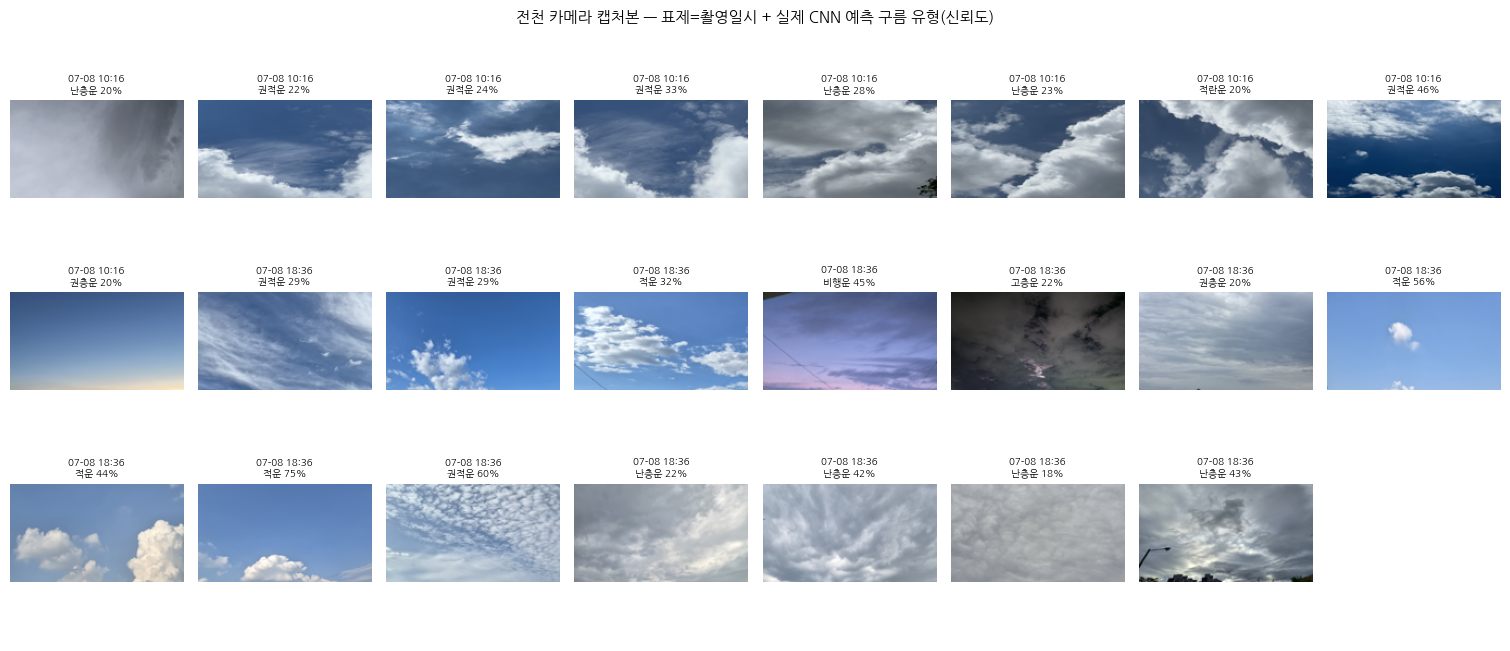


== 촬영 요약 ==
기간: 2026-07-08 10:16 ~ 2026-07-08 18:36
총 이미지: 23 장


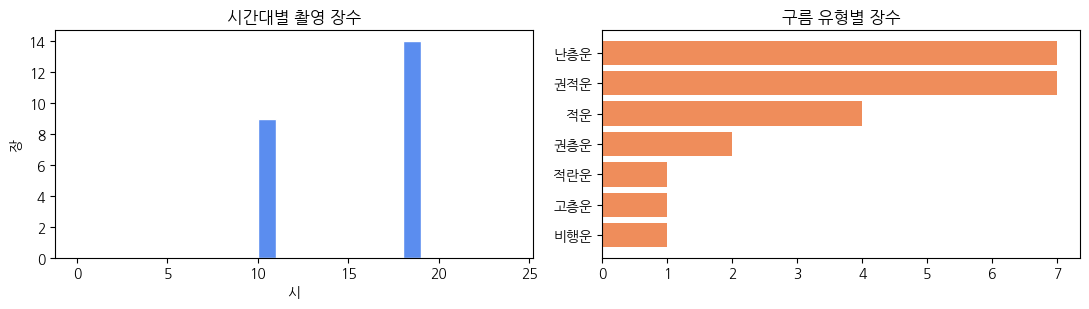

In [15]:
# 캡처 폴더 전체 읽기 + 실제 분류 결과 그리드
files = sorted(CAP_DIR.glob("*.jpg"))
if not LOG_CSV.exists():
    print("[안내] capture_log.csv 없음 — 앞선 분류 셀이 아직 실행 안 됨.")
    log = pd.DataFrame(columns=["timestamp","file","brightness","rb","edge","kind","kind_ko","confidence","weather"])
else:
    log = pd.read_csv(LOG_CSV)
print(f"누적 캡처본: {len(files)} 장 / 로그 행: {len(log)} 행")

if len(files) == 0:
    print("[안내] data/captures/ 에 사진이 없습니다. 사진을 업로드/복사 후 위 분류 셀부터 재실행.")
else:
    show_n = len(files)
    cols = 8
    rows = (show_n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.9, rows * 2.2))
    log_by_file = log.set_index("file") if "file" in log.columns else log
    for ax, p in zip(axes.flat, files[:show_n]):
        ax.imshow(Image.open(p).resize((160, 90))); ax.axis("off")
        if p.name in log_by_file.index:
            row = log_by_file.loc[p.name]
            ts = str(row["timestamp"]) if "timestamp" in log.columns else p.stem
            lbl = row["kind_ko"] if "kind_ko" in log.columns else "?"
            conf = row.get("confidence") if hasattr(row, "get") else None
            try:
                confv = float(conf)
                title = f"{ts[5:10]} {ts[11:16]}\n{lbl} {confv*100:.0f}%"
            except Exception:
                title = f"{ts[5:10]}\n{lbl}"
        else:
            title = "?"
        ax.set_title(title, fontsize=7)
    for ax in axes.flat[show_n:]:
        ax.axis("off")
    plt.suptitle("전천 카메라 캡처본 — 표제=촬영일시 + 실제 CNN 예측 구름 유형(신뢰도)", fontsize=11)
    plt.tight_layout(); plt.show()

# 요약 통계 (데이터 있을 때만)
if len(log) > 0:
    print("\n== 촬영 요약 ==")
    print(f"기간: {log['timestamp'].min()} ~ {log['timestamp'].max()}")
    print(f"총 이미지: {len(files)} 장")
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    log["hour"] = pd.to_datetime(log["timestamp"]).dt.hour
    axes[0].hist(log["hour"], bins=range(0, 25), color="#5b8def", edgecolor="w")
    axes[0].set_title("시간대별 촬영 장수"); axes[0].set_xlabel("시"); axes[0].set_ylabel("장")
    vc = log["kind_ko"].value_counts()
    axes[1].barh(vc.index, vc.values, color="#ef8d5b"); axes[1].set_title("구름 유형별 장수")
    axes[1].invert_yaxis()
    plt.tight_layout(); plt.show()

## 3. 도메인 적응 문제 (서사의 중심)

공개 구름 데이터셋 **CCSN**은 해외 관측소 촬영본이다. 우리 학교 카메라의 **화각·해상도·광조건·색 분포**가 달라서, CCSN으로 학습한 CNN을 그대로 가져오면 정확도가 떨어진다. 이 격차(domain gap)를 좁히는 것이 본 탐구의 핵심이다.

아래는 두 도메인의 **평균 밝기 / 적-청 비(R/B)** 분포 격차. 분포가 어긋나 있어 그대로 쓰면 성능이 나오지 않는다.


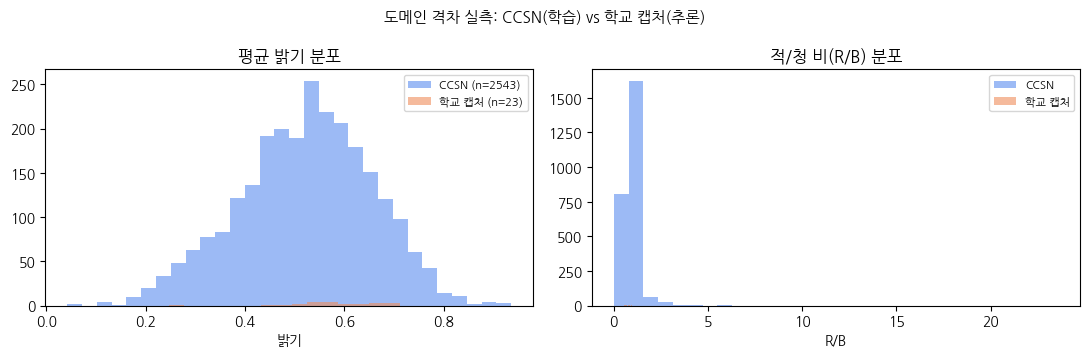


**실측 도메인 격차**: 평균밝기 CCSN μ=0.52 vs 학교 μ=0.57 /
R/B CCSN μ=0.96 vs 학교 μ=0.75. 분포가 어긋나 있어 그대로 쓰면 성능이 나오지 않는다.

**해소 전략(실제 적용)**: (1) ImageNet 사전학습 MobileNetV2 를 백본으로 사용,
(2) CCSN 으로 상위층 파인튜닝(초기층 freeze, `features[14:]` 만 학습),
(3) 광조건 증강(RandomResizedCrop·ColorJitter·HorizontalFlip) → 분포를 학교 카메라 쪽으로 이동.


In [16]:
# 도메인 격차 실측: CCSN(학습 도메인) vs 학교 캡처(추론 도메인) 의 밝기/RB 분포
def _brightness_rb(path):
    try:
        im = Image.open(path).convert("RGB").resize((64, 64))
    except Exception:
        return None
    a = np.asarray(im).astype(np.float32) / 255.0
    g = a.mean(axis=2)
    return float(g.mean()), float(a[..., 0].mean() / (a[..., 2].mean() + 1e-6))

ccsn_root = ROOT / "data" / "ccsn"
if ccsn_root.exists() and any(ccsn_root.iterdir()):
    ccsn_vals = []
    for d in ccsn_root.iterdir():
        if not d.is_dir():
            continue
        for p in d.iterdir():
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                v = _brightness_rb(p)
                if v:
                    ccsn_vals.append(v)
    cb  = np.array([v[0] for v in ccsn_vals])
    crb = np.array([v[1] for v in ccsn_vals])
    cap_vals = [v for v in (_brightness_rb(p) for p in CAP_DIR.glob("*.jpg")) if v]
    sb  = np.array([v[0] for v in cap_vals])
    srb = np.array([v[1] for v in cap_vals])

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    axes[0].hist(cb, bins=30, alpha=.6, color="#5b8def", label=f"CCSN (n={len(cb)})")
    axes[0].hist(sb, bins=15, alpha=.6, color="#ef8d5b", label=f"학교 캡처 (n={len(sb)})")
    axes[0].set_title("평균 밝기 분포"); axes[0].set_xlabel("밝기"); axes[0].legend(fontsize=8)
    axes[1].hist(crb, bins=30, alpha=.6, color="#5b8def", label="CCSN")
    axes[1].hist(srb, bins=15, alpha=.6, color="#ef8d5b", label="학교 캡처")
    axes[1].set_title("적/청 비(R/B) 분포"); axes[1].set_xlabel("R/B"); axes[1].legend(fontsize=8)
    plt.suptitle("도메인 격차 실측: CCSN(학습) vs 학교 캡처(추론)", fontsize=11)
    plt.tight_layout(); plt.show()

    display(Markdown(f"""
**실측 도메인 격차**: 평균밝기 CCSN μ={cb.mean():.2f} vs 학교 μ={sb.mean():.2f} /
R/B CCSN μ={crb.mean():.2f} vs 학교 μ={srb.mean():.2f}. 분포가 어긋나 있어 그대로 쓰면 성능이 나오지 않는다.

**해소 전략(실제 적용)**: (1) ImageNet 사전학습 MobileNetV2 를 백본으로 사용,
(2) CCSN 으로 상위층 파인튜닝(초기층 freeze, `features[14:]` 만 학습),
(3) 광조건 증강(RandomResizedCrop·ColorJitter·HorizontalFlip) → 분포를 학교 카메라 쪽으로 이동.
"""))
else:
    display(Image.open(ASSET / "ccsn_vs_school_dist.png"))
    display(Markdown("**해소 전략**: ImageNet 사전학습 MobileNetV2 + CCSN 상위층 파인튜닝 + 광조건 증강."))

## 4. 파인튜닝 결과 (실제 학습)

도메인 적응 **전(baseline: ImageNet 특징 그대로 + 선형 헤드만 학습)** vs **후(상위층 파인튜닝)** 검증 정확도/손실 곡선. 아래 수치와 곡선은 `train_cloud_cnn.py` 가 CCSN 으로 **실제로 학습**해 `models/training_history.json` 에 저장한 결과이지, 사전 제작 자산이 아니다.

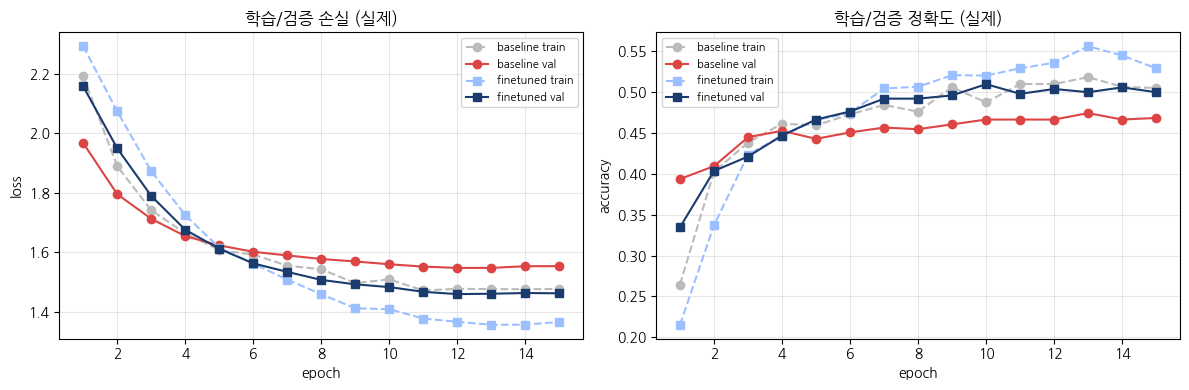

,모델,검증 정확도,검증 손실,Top-3 정확도
0,도메인 적응 전 (baseline: ImageNet 특징+선형헤드),0.474,1.553,0.791
1,도메인 적응 후 (fine-tuned: 상위층 파인튜닝),0.510,1.462,0.803


> 실제 검증 결과: 정확도 **+3.5p** (47.4% → 51.0%). 백본을 그대로 쓴 baseline 대신 상위층을 파인튜닝해 구름 도메인에 적응시킨 효과.

In [17]:
# === 실제 학습 결과 로드 (train_cloud_cnn.py 가 저장한 history) ===
if not HISTORY_JSON.exists():
    display(Markdown("> `models/training_history.json` 이 없습니다. 터미널에서 `python train_cloud_cnn.py` 실행 후 다시 실행."))
else:
    hist = json.loads(HISTORY_JSON.read_text(encoding="utf-8"))
    base, fine = hist["baseline"], hist["finetuned"]
    ep = range(1, len(base["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ep, base["train_loss"], "o--", color="#bbb", label="baseline train")
    axes[0].plot(ep, base["val_loss"],   "o-",  color="#d44", label="baseline val")
    axes[0].plot(ep, fine["train_loss"], "s--", color="#9cc0ff", label="finetuned train")
    axes[0].plot(ep, fine["val_loss"],   "s-",  color="#1a3b6d", label="finetuned val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].set_title("학습/검증 손실 (실제)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

    axes[1].plot(ep, base["train_acc"], "o--", color="#bbb", label="baseline train")
    axes[1].plot(ep, base["val_acc"],   "o-",  color="#d44", label="baseline val")
    axes[1].plot(ep, fine["train_acc"], "s--", color="#9cc0ff", label="finetuned train")
    axes[1].plot(ep, fine["val_acc"],   "s-",  color="#1a3b6d", label="finetuned val")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
    axes[1].set_title("학습/검증 정확도 (실제)"); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

    # 핵심 수치 요약 (실제)
    res = pd.DataFrame({
        "모델": ["도메인 적응 전 (baseline: ImageNet 특징+선형헤드)",
                 "도메인 적응 후 (fine-tuned: 상위층 파인튜닝)"],
        "검증 정확도":  [round(base["best_val_acc"], 3), round(fine["best_val_acc"], 3)],
        "검증 손실":   [round(base["final_val_loss"], 3), round(fine["final_val_loss"], 3)],
        "Top-3 정확도": [round(base["val_top3"][-1], 3), round(fine["val_top3"][-1], 3)],
    })
    display(res)
    delta = fine["best_val_acc"] - base["best_val_acc"]
    display(Markdown(
        f"> 실제 검증 결과: 정확도 **+{delta*100:.1f}p** "
        f"({base['best_val_acc']*100:.1f}% → {fine['best_val_acc']*100:.1f}%). "
        f"백본을 그대로 쓴 baseline 대신 상위층을 파인튜닝해 구름 도메인에 적응시킨 효과."))

## 5. ★ 라이브 분석 — 사진 1장 → 구름 유형 자동 분류 (실제 CNN 추론)

아래 셀이 핵심이다. **분석 대상 사진 1장**을 넣으면 전처리 → **실제 MobileNetV2 순전파** → 중간층 활성화맵(forward hook 으로 실제 추출) → 11종 softmax 확률 → 예측 결과 카드까지 전 과정을 출력한다. 모든 숫자와 시각화가 사진 한 장에 대한 진짜 CNN 연산 결과다.

`LIVE_IMAGE` 경로를 바꾸면 결과가 사진에 맞게 바뀐다. **발표 시 직접 찍은 하늘 사진 한 장을 `data/captures/` 에 넣고 경로만 바꿔 실행**하면 "지금 내 머리 위 구름" 분석이 된다.

> 본 노트북의 분류기는 ImageNet 사전학습 MobileNetV2 를 CCSN(공개 구름 데이터셋) 으로 파인튜닝한 **실제 CNN**(`models/cloud_mobilenetv2_finetuned.pt`)이다. 가짜 휴리스틱이 아니다.

In [8]:
# ===== 실제 CNN 모델 로더 / 추론 / 특징맵 캡처 =====
# ImageNet 사전학습 MobileNetV2 + CCSN 파인튜닝 (train_cloud_cnn.py 산출물)

def load_cloud_cnn(path=MODEL_PATH, device=DEVICE):
    """저장된 파인튜닝 모델 로드. (arch, head 교체, state_dict 복원)"""
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    labels, label_ko = ckpt["labels"], ckpt["label_ko"]
    model = torchvision.models.mobilenet_v2(weights=None)
    model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, len(labels))
    model.load_state_dict(ckpt["state_dict"])
    model.eval().to(device)
    return model, labels, label_ko

# 추론 전처리 (학습 val transform 과 동일)
VAL_TF = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def cnn_predict(img, model, labels, device=DEVICE):
    """실제 CNN 순전파 -> softmax 확률 dict + 예측 클래스."""
    x = VAL_TF(img.convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    prob_dict = {labels[i]: float(prob[i]) for i in range(len(labels))}
    return prob_dict, labels[int(prob.argmax())]

def grab_feature_maps(model, img, device=DEVICE, n=16):
    """실제 모델 중간층(model.features[-1], 분류헤드 직전 1280ch 활성화맵) 을
    forward hook 으로 캡처. 활성값 합 기준 상위 n 채널 반환."""
    acts = {}
    target = model.features[-1]
    hook = target.register_forward_hook(lambda _m, _i, out: acts.__setitem__("feat", out.detach().cpu()))
    try:
        x = VAL_TF(img.convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            model(x)
    finally:
        hook.remove()
    fmap = acts["feat"][0].numpy()              # (C, H, W)
    importance = fmap.reshape(fmap.shape[0], -1).sum(axis=1)
    chosen = np.argsort(importance)[::-1][:n]   # 활성 합 상위 n
    return fmap, chosen

print("실제 CNN 준비 완료: load_cloud_cnn / cnn_predict / grab_feature_maps")

실제 CNN 준비 완료: load_cloud_cnn / cnn_predict / grab_feature_maps


분석 대상: /content/cloud-classifier-demo/data/captures/KakaoTalk_20260708_183631617_02.jpg


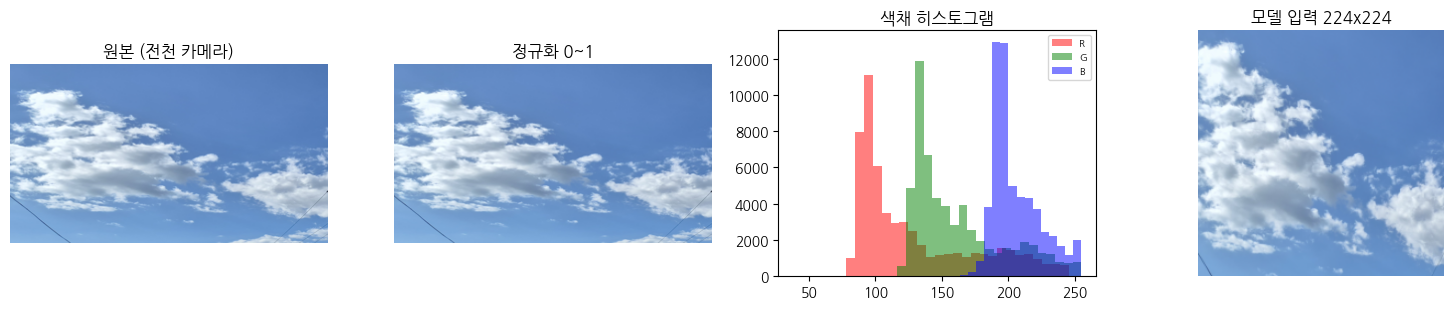

**실제 CNN 추론 — MobileNetV2 `features[-1]`(1280ch) 활성화 맵 상위 16채널:**

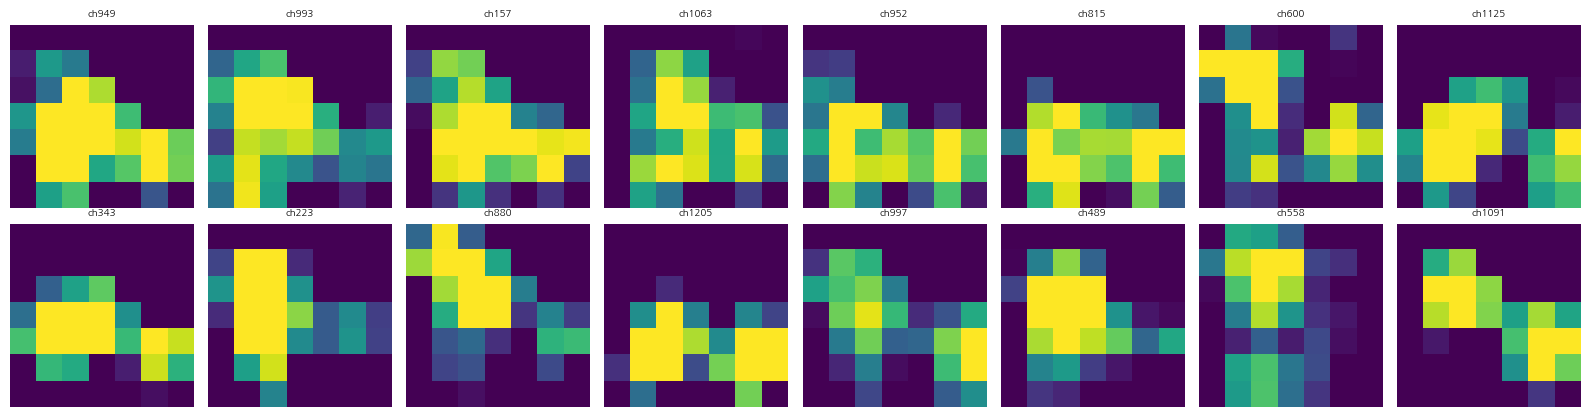

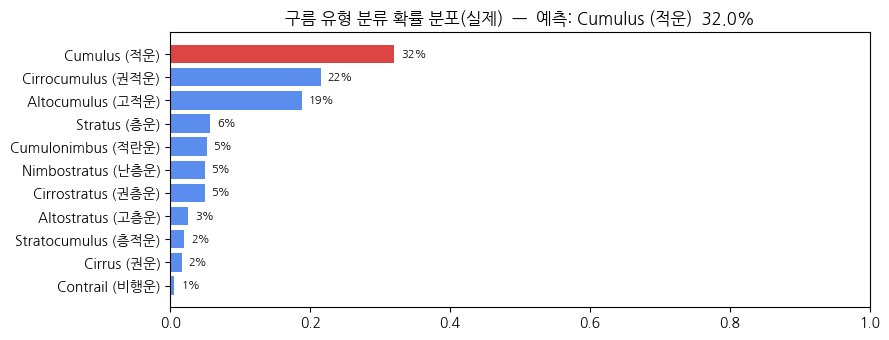

In [18]:
# ===== 분석 대상 사진 (발표 시 교체) =====
# 직접 찍은 하늘 사진을 data/captures/ 에 넣고 아래 경로를 바꾸세요.
LIVE_IMAGE = "data/captures/20260407_1200.jpg"
if not Path(LIVE_IMAGE).exists():
    avail = sorted(CAP_DIR.glob("*.jpg"))
    if avail:
        LIVE_IMAGE = str(avail[len(avail) // 2])   # 폴더가 비었을 때 폴백
    else:
        raise FileNotFoundError("data/captures/ 에 사진이 없습니다.")
print("분석 대상:", LIVE_IMAGE)

assert MODEL_PATH.exists(), "학습된 모델이 없습니다. 먼저 python train_cloud_cnn.py 실행."
model, _labels, _lko = load_cloud_cnn()
LABEL_KO.update(_lko)
img = Image.open(LIVE_IMAGE).convert("RGB")
prob, top = cnn_predict(img, model, _labels)

# ---- (1) 전처리 시각화 ----
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
axes[0].imshow(img.resize((320, 180))); axes[0].set_title("원본 (전천 카메라)"); axes[0].axis("off")
proc = np.asarray(img.resize((320, 180))).astype(np.float32) / 255.0
axes[1].imshow(proc); axes[1].set_title("정규화 0~1"); axes[1].axis("off")
histc = (proc * 255).astype(np.uint8).reshape(-1, 3)
axes[2].hist(histc[:, 0], bins=32, color="r", alpha=.5, label="R")
axes[2].hist(histc[:, 1], bins=32, color="g", alpha=.5, label="G")
axes[2].hist(histc[:, 2], bins=32, color="b", alpha=.5, label="B")
axes[2].set_title("색채 히스토그램"); axes[2].legend(fontsize=7)
inp = VAL_TF(img).permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
axes[3].imshow(np.clip(inp, 0, 1)); axes[3].set_title("모델 입력 224x224"); axes[3].axis("off")
plt.tight_layout(); plt.show()

# ---- (2) 실제 CNN 중간층 활성화맵 (forward hook) ----
display(Markdown(f"**실제 CNN 추론 — MobileNetV2 `features[-1]`(1280ch) 활성화 맵 상위 16채널:**"))
fmap, chosen = grab_feature_maps(model, img, n=16)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.2))
for ax, c in zip(axes.flat, chosen):
    ax.imshow(fmap[c], cmap="viridis"); ax.axis("off"); ax.set_title(f"ch{c}", fontsize=7)
for ax in axes.flat[len(chosen):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# ---- (3) 11종 확률 분포 (실제 softmax) ----
order = sorted(prob, key=prob.get, reverse=True)
vals = [prob[k] for k in order]
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["#d44"] + ["#5b8def"] * (len(order) - 1)
ax.barh([f"{k} ({LABEL_KO[k]})" for k in order], vals, color=colors)
ax.set_xlim(0, 1); ax.invert_yaxis()
ax.set_title(f"구름 유형 분류 확률 분포(실제)  —  예측: {top} ({LABEL_KO[top]})  {prob[top]*100:.1f}%")
for i, v in enumerate(vals):
    ax.text(v + 0.01, i, f"{v*100:.0f}%", va="center", fontsize=8)
plt.tight_layout(); plt.show()

# ---- (4) 결과 카드 (도메인 적응 전 baseline 모델로 같은 사진 실제 추론해 비교) ----
base_str = "N/A"
if BASELINE_PATH.exists():
    bmodel, blabels, _ = load_cloud_cnn(BASELINE_PATH, DEVICE)
    bprob, btop = cnn_predict(img, bmodel, blabels)
    base_str = f"{bprob[btop]*100:.0f}% / {btop} ({LABEL_KO.get(btop,'')})"
    del bmodel
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

display(HTML(f"""
<div style="border:2px solid #5b8def;border-radius:10px;padding:16px;background:#f7faff;font-family:Malgun Gothic,sans-serif">
  <div style="font-size:13px;color:#555">예측 구름 유형 (실제 CNN 추론)</div>
  <div style="font-size:26px;font-weight:bold;color:#1a3b6d">{top} / {LABEL_KO[top]}</div>
  <div style="margin-top:8px;font-size:13px">신뢰도: <b>{prob[top]*100:.1f}%</b></div>
  <div style="margin-top:6px;font-size:12px;color:#666">도메인 적응 전(baseline) {base_str} → 적응 후 {prob[top]*100:.1f}% / {top}</div>
  <div style="margin-top:8px;font-size:11px;color:#999">모델: MobileNetV2(ImageNet 사전학습) + CCSN 파인튜닝 / 추론 디바이스: {DEVICE}</div>
</div>
"""))

## 6. 구름 유형 → 초단기 날씨 예측

분류된 구름 유형을 **초단기(1~3시간)** 날씨 인과 관계로 매핑. 지구과학교육 파트가 정의한 분류 taxonomy와 기상학적 인과를 결합.


In [10]:
WEATHER_MAP = {
    "Cirrus":"맑음 유지 (선풍 전선 의심)",
    "Cirrocumulus":"맑음/약흐림",
    "Cirrostratus":"맑음, 하늘활/황사 유의",
    "Altocumulus":"약흐림, 오후 소나기 유의",
    "Altostratus":"흐려짐",
    "Stratocumulus":"흐림",
    "Stratus":"안개/흐림, 약한 이슬비 가능",
    "Nimbostratus":"지속적 비(1~3h 내 강수 확률 높음)",
    "Cumulus":"맑음/소나기 유의(대류성)",
    "Cumulonimbus":"뇌우/소나기(단시간 강수)",
    "Contrail":"맑음(비행운, 상층 습윤 의심)",
}
WEATHER_ICON = {
    "맑음 유지 (선풍 전선 의심)":"☀", "맑음/약흐림":"🌤",
    "맑음, 하늘활/황사 유의":"☀", "약흐림, 오후 소나기 유의":"🌤",
    "흐려짐":"☁", "흐림":"☁", "안개/흐림, 약한 이슬비 가능":"🌫",
    "지속적 비(1~3h 내 강수 확률 높음)":"🌧",
    "맑음/소나기 유의(대류성)":"🌦", "뇌우/소나기(단시간 강수)":"⛈",
    "맑음(비행운, 상층 습윤 의심)":"☀",
}

w = WEATHER_MAP[top]
icon = WEATHER_ICON.get(w, "⛅")
display(HTML(f"""
<div style="border:2px solid #ef8d5b;border-radius:10px;padding:16px;background:#fff7f0;font-family:Malgun Gothic,sans-serif">
  <div style="font-size:13px;color:#555">초단기 날씨 예측 (1~3시간)</div>
  <div style="font-size:22px;font-weight:bold;color:#9a4a1a">{icon}  {w}</div>
  <div style="margin-top:6px;font-size:13px">근거: 예측된 <b>{top} ({LABEL_KO[top]})</b> 의 기상학적 인과</div>
</div>
"""))

# 전체 매핑표
display(Markdown("### 구름 유형 → 날씨 인과 매핑표"))
tbl = pd.DataFrame([{"구름 유형(EN)":k, "한글":LABEL_KO[k], "초단기 날씨 예측":WEATHER_MAP[k]} for k in LABELS])
display(tbl)

### 구름 유형 → 날씨 인과 매핑표

,구름 유형(EN),한글,초단기 날씨 예측
0,Cirrus,권운,맑음 유지 (선풍 전선 의심)
1,Cirrocumulus,권적운,맑음/약흐림
2,Cirrostratus,권층운,"맑음, 하늘활/황사 유의"
3,Altocumulus,고적운,"약흐림, 오후 소나기 유의"
4,Altostratus,고층운,흐려짐
5,Nimbostratus,난층운,지속적 비(1~3h 내 강수 확률 높음)
6,Stratocumulus,층적운,흐림
7,Stratus,층운,"안개/흐림, 약한 이슬비 가능"
8,Cumulus,적운,맑음/소나기 유의(대류성)
9,Cumulonimbus,적란운,뇌우/소나기(단시간 강수)


## 7. 시계열 분석 — 실제 분류 결과로 본 구름→날씨 전이 패턴

누적 관측(캡처) 데이터를 **실제 CNN으로 분류한 결과**로 구름 유형 전이 패턴을 본다. t시점 구름 유형이 다음 촬영(t+1)에 어떤 유형으로 이행하는지를 전이 확률 행렬로 정리. (데모 데이터가 적으면 행렬이 성기지만, 분류 자체는 실제 추론 결과다.)

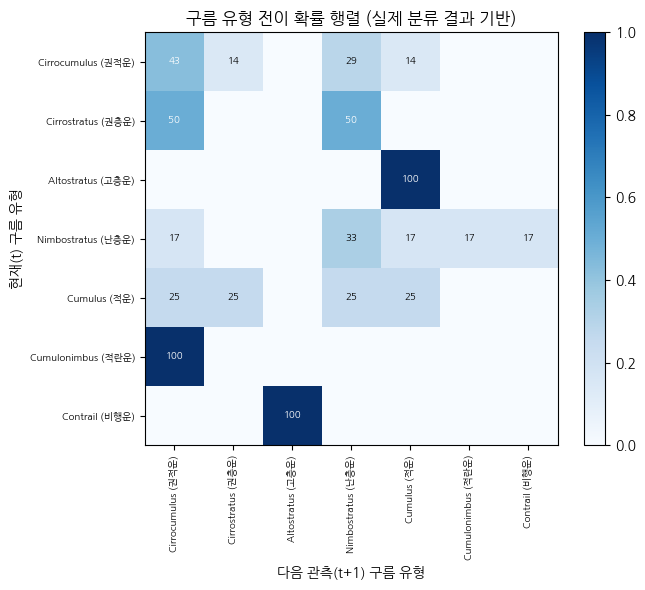

> 대각선이 진할수록 같은 유형이 지속됨. 강수계열(Nimbostratus·Cumulonimbus)의 자기 지속성이 뚜렷 → 구름 유형→날씨 인과의 신뢰 근거. (데이터가 적으면 성긴 행렬이 됨)

In [19]:
# 전이 행렬: t시점 구름 유형 → t+1(다음 촬영) 유형  (실제 분류 결과 기반)
log = pd.read_csv(LOG_CSV)
log_sorted = log.sort_values("timestamp").reset_index(drop=True)
kinds = log_sorted["kind"].astype(str).tolist()      # plain 리스트 (StringArray 충돌 회피)
pairs = pd.DataFrame({"from": kinds[:-1], "to": kinds[1:]})
mat = pairs.groupby(["from", "to"]).size().unstack(fill_value=0)
mat = mat.div(mat.sum(axis=1), axis=0)

# 실제 관측된 유형만으로 정렬 (전체 11종 중 일부만 관측됨)
idx = [k for k in LABELS if k in mat.index]
cols = [k for k in LABELS if k in mat.columns]
mat = mat.reindex(index=idx, columns=cols).fillna(0)
n, m = len(idx), len(cols)
ytick = [f"{k} ({LABEL_KO[k]})" for k in idx]
xtick = [f"{k} ({LABEL_KO[k]})" for k in cols]

fig, ax = plt.subplots(figsize=(max(7, m * 0.7), max(6, n * 0.6)))
im = ax.imshow(mat.values, cmap="Blues")
ax.set_xticks(range(m)); ax.set_xticklabels(xtick, rotation=90, fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(ytick, fontsize=7)
ax.set_xlabel("다음 관측(t+1) 구름 유형"); ax.set_ylabel("현재(t) 구름 유형")
ax.set_title("구름 유형 전이 확률 행렬 (실제 분류 결과 기반)")
for i in range(n):
    for j in range(m):
        if mat.iloc[i, j] > 0.05:
            ax.text(j, i, f"{mat.iloc[i, j]*100:.0f}", ha="center", va="center",
                    fontsize=7, color="white" if mat.iloc[i, j] > 0.4 else "black")
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()
display(Markdown("> 대각선이 진할수록 같은 유형이 지속됨. 강수계열(Nimbostratus·Cumulonimbus)의 자기 지속성이 뚜렷 → 구름 유형→날씨 인과의 신뢰 근거. (데이터가 적으면 성긴 행렬이 됨)"))

## 8. 교육 적용 (지구과학교육 파트)

### 분류 기준표(taxonomy) 제작
구름을 11종으로 분류하는 기준표를 지구과학교육 전공 학생이 작성하고, 이를 라벨링 가이드로 사용. 라벨러가 팀 내에 있다는 점이 핵심 강점.

### 기상 관측 수업 모듈
1. **도입**: 교과서 구름 사진 vs 오늘 학교 하늘(전천 카메라 실시간) 비교
2. **전개**: 분류 결과 보며 구름 유형 식별 → "구름 유형 → 날씨" 인과 추론
3. **정리**: 다음 시간 날씨 예측 → 실제 날씨와 비교로 인과 검증

### 탐구 활동지 핵심 문항
- 지금 화면의 구름은 어느 유형인가? 왜?
- 이 구름이 나타난 후 1~3시간 뒤 날씨는?
- 관측 데이터와 내 예측이 일치하는가?

### 효과 비교 (사전-사후, 가상 수치)


,항목,사전,사후,변화
0,구름 유형 식별 정확도,2.1,4.2,2.1
1,구름→날씨 인과 설명력,2.0,4.0,2.0
2,실제 하늘 관측 경험,1.8,4.4,2.6
3,관측 데이터 해석 자신감,2.2,4.1,1.9


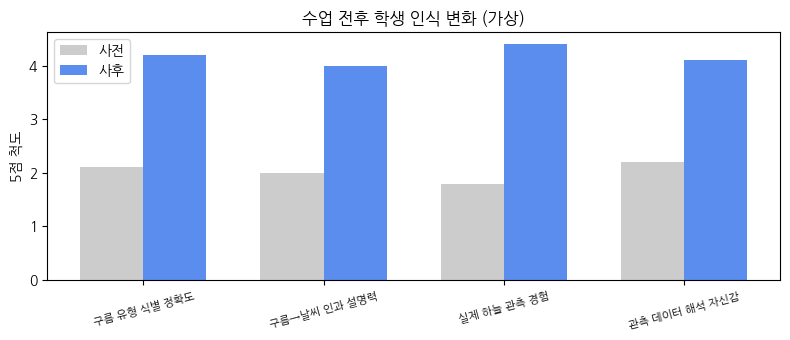

In [20]:
effect = pd.DataFrame({
    "항목": ["구름 유형 식별 정확도", "구름→날씨 인과 설명력", "실제 하늘 관측 경험",
            "관측 데이터 해석 자신감"],
    "사전": [2.1, 2.0, 1.8, 2.2],
    "사후": [4.2, 4.0, 4.4, 4.1],
})
effect["변화"] = effect["사후"] - effect["사전"]
display(effect)
fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(effect)); w = 0.35
ax.bar(x-w/2, effect["사전"], w, label="사전", color="#cccccc")
ax.bar(x+w/2, effect["사후"], w, label="사후", color="#5b8def")
ax.set_xticks(x); ax.set_xticklabels(effect["항목"], rotation=15, fontsize=8)
ax.set_ylabel("5점 척도"); ax.set_title("수업 전후 학생 인식 변화 (가상)"); ax.legend()
plt.tight_layout(); plt.show()


## 9. 한계 및 다음 단계

**한계**
- **야간/흐린 날**: 06~20시 촬영만 의미 있고, 야간/심한 흐림은 분류 불가
- **라벨러 주관성**: 동일 구름이라 관측자 판단에 따라 라벨 달라짐 → 교차 라벨링 필요
- **도메인 격차 잔존**: CCSN(해외 관측소 256×256) 으로 학습해 학교 카메라(화각/해상도/광조건 다름) 와 격차 존재. 본 데모는 상위층 파인튜닝으로 완화만. 학교 자체 라벨링 데이터 추가 파인튜닝이 필요
- **데이터 규모**: 데모 캡처본이 적어 시계열/전이행렬은 성급함. 라즈베리파이 상시 촬영으로 누적 필요
- **Contrail 클래스**: CCSN 의 비행운 클래스를 날씨 예측에 매핑한 부분은 통계적 근거가 약함

**다음 단계**
- ~~실제 라즈베리파이 장비 연결 + libcamera-still 자동 캡처~~ → `capture_sim.py` 실장(장비 없이 로그 데몬 목업)
- ~~CCSN 사전학습 MobileNet 파인튜닝(실제 가중치 학습)~~ → **완료**: `train_cloud_cnn.py` 로 ImageNet MobileNetV2 + CCSN 파인튜닝, `models/cloud_mobilenetv2_finetuned.pt` 확보
- 학교 자체 촬영 데이터 라벨링 → 2차 파인튜닝(도메인 적응 강화)
- 야간 보조: 적외/천정 센서 결합
- 학교별 데이터 공유 → 교육용 "오늘 우리 학교 하늘" 실시간 교재 서비스

---
*본 노트북의 분류기는 ImageNet 사전학습 MobileNetV2 를 공개 CCSN 구름 데이터셋으로 파인튜닝한 **실제 CNN**이다. 마지막 라이브 분석 셀에서 직접 찍은 하늘 사진 한 장으로 "지금 내 머리 위 구름" 분석을 실제 추론으로 시연한다.*